Analiza zbioru danych z poprzedniego ćwiczenia - wybór cech
-----------------------------------------------------------


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LinearRegression

import shap

Wczytanie zbioru danych - tym razem "oficjalnie"

In [2]:
raw = load_breast_cancer()
X_df = pd.DataFrame(raw.data, columns=raw.feature_names)
y = raw.target

Celem analizy jest wyodrębnienie cech które w największym stopniu wpływają na
wynik klasyfikacji. Wymaga to okreslenia modelu, przy pomocy którego będziemy
oceniać wpływ poszczególnych cech.

Poniżej, do wyboru - liniowa regresja (proste podejcie), klasyfikator 
drzewa decyzyjnego (bardziej złożona metoda)

In [3]:
use_classifier = False

Inicjalizacja modelu, trenowanie, wyznaczenie wartosci SHAP.

In [4]:
model = GradientBoostingClassifier() if use_classifier else LinearRegression()
model.fit(X_df, y)
explainer = shap.Explainer(model, X_df)
shap_exp  = explainer(X_df)

Całkowity uśredniony wkład poszczególnych cech.

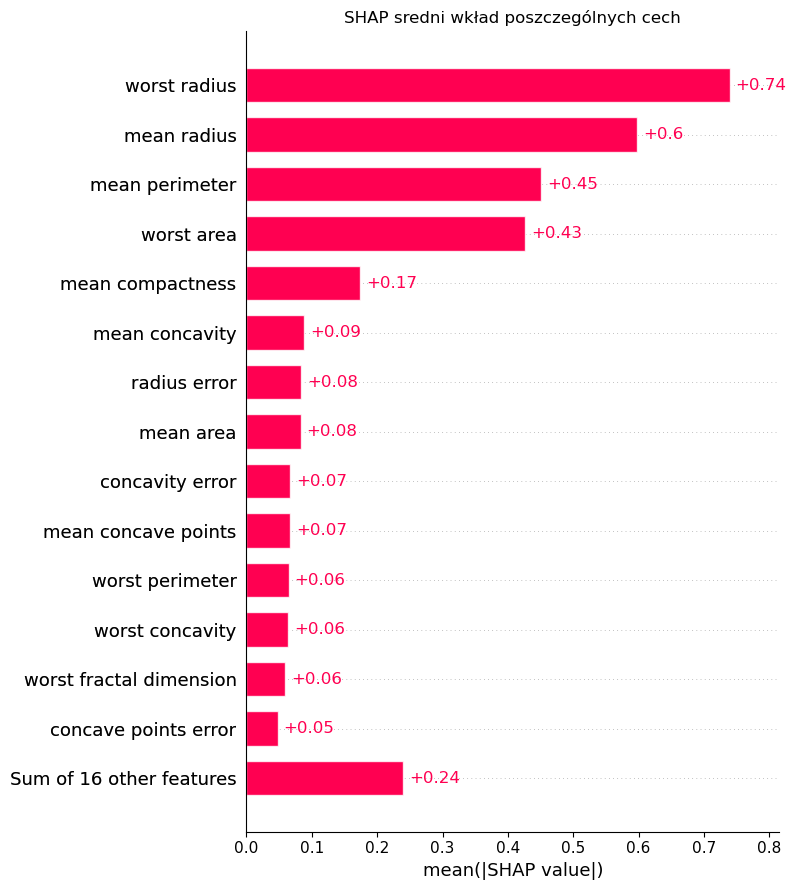

In [5]:
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title("SHAP sredni wkład poszczególnych cech")
plt.tight_layout()
plt.show()

Bardziej szczegółowo, dla indywidualnych pacjentów.

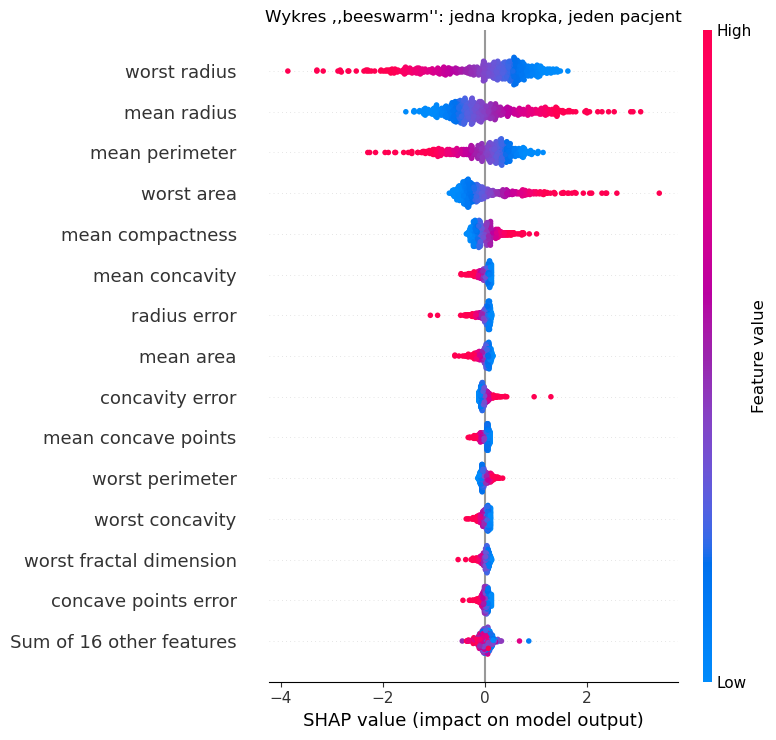

In [6]:
shap.plots.beeswarm(shap_exp, max_display=15, color_bar=True, show=False)
plt.title("Wykres ,,beeswarm'': jedna kropka, jeden pacjent")
plt.tight_layout()
plt.show()

Które dwie cechy są najistotniejsze według analizy SHAP?

In [7]:
feature_contribution = np.abs(shap_exp.values).mean(axis=0)
two_best_index = np.argsort(feature_contribution)[::-1][:2]
two_best_names = raw.feature_names[two_best_index]
print(two_best_names)

['worst radius' 'mean radius']
